#### Data Cleaning & Feature Engineering

**Project**: Steel Sales Performance & Market Insights Dashboard  
**Input**: `../data/raw_rebar_sales_2020_2026.csv` 

**Goals**:
- Load and inspect raw data
- Handle data types, missing values, duplicates, outliers
- Add time-based features (Year, Quarter, Month, Season)
- Add business features: YoY growth, estimated margin %, Revenue per ton, etc.
- Ensure data quality for accurate analysis & dashboard

#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

#### Load Raw Data & Initial Inspection

In [2]:
df = pd.read_csv('../data/raw_rebar_sales_2020_2026.csv')

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print("Shape:", df.shape)
print("\nColumns and types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDate range:", df['Order_Date'].min().date(), "to", df['Order_Date'].max().date())
print("\nSample head:\n")
display(df.head())

Shape: (7000, 8)

Columns and types:
 Order_Date           datetime64[ns]
Product                      object
Quantity_kg                   int64
Unit_Price_ETB_kg           float64
Revenue_ETB                   int64
Region                       object
Customer_Type                object
Customer_Name                object
dtype: object

Missing values:
 Order_Date           0
Product              0
Quantity_kg          0
Unit_Price_ETB_kg    0
Revenue_ETB          0
Region               0
Customer_Type        0
Customer_Name        0
dtype: int64

Date range: 2020-01-31 to 2026-06-30

Sample head:



,Order_Date,Product,Quantity_kg,Unit_Price_ETB_kg,Revenue_ETB,Region,Customer_Type,Customer_Name
0,2020-01-31,Rebar 6mm G60,1000,181.44,181440,Sidama,Government Project,Sidama Public Works
1,2020-01-31,Rebar 12mm G75,200,156.92,31384,Addis Ababa,Government Project,Ethiopian Roads Authority Contractor
2,2020-01-31,Rebar 12mm G75,17700,161.78,2863506,Addis Ababa,Wholesaler,Amhara Construction Materials Wholesaler PLC
3,2020-01-31,Rebar 8mm G75,6100,157.74,962214,Oromia,Medium Contractor,MEDCON Engineering & Construction
4,2020-01-31,Rebar 14mm G75,1400,160.90,225260,Addis Ababa,Medium Contractor,Amaga PLC


#### Duplicates, Validation & Outlier Handling



In [3]:
# 1. Duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

# 2. Validate ranges (realistic checks)
print("\nPrice stats before cleaning:\n", df['Unit_Price_ETB_kg'].describe().round(2))
print("\nQuantity stats:\n", df['Quantity_kg'].describe().round(0))

# Cap extreme outliers
price_upper = 500
qty_upper   = 100_000  # 100 tons

df = df[
    (df['Unit_Price_ETB_kg'] >= 80) & 
    (df['Unit_Price_ETB_kg'] <= price_upper) &
    (df['Quantity_kg'] <= qty_upper)
]

print(f"\nRows after range filtering: {len(df)}")

# 3. No missing values expected → but fill just in case
df = df.fillna({
    'Unit_Price_ETB_kg': df['Unit_Price_ETB_kg'].median(),
    'Revenue_ETB': df['Quantity_kg'] * df['Unit_Price_ETB_kg']
})

Number of duplicate rows: 0

Price stats before cleaning:
 count    7000.00
mean      247.28
std        80.97
min       105.87
25%       182.20
50%       239.01
75%       302.36
max       493.16
Name: Unit_Price_ETB_kg, dtype: float64

Quantity stats:
 count       7000.0
mean        9109.0
std        26467.0
min          100.0
25%         1100.0
50%         3000.0
75%         8200.0
max      1076600.0
Name: Quantity_kg, dtype: float64

Rows after range filtering: 6938


#### Add Time-Based Features



In [4]:
# Extract time components
df['Year']       = df['Order_Date'].dt.year
df['Quarter']    = df['Order_Date'].dt.quarter
df['Month']      = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')
df['Day']        = df['Order_Date'].dt.day

# Add Season (Dry: Nov-May, Wet: Jun-Oct)
df['Season'] = np.where(df['Month'].isin([11,12,1,2,3,4,5]), 'Dry', 'Wet')

print("New time features added. Sample:")
display(df[['Order_Date', 'Year', 'Quarter', 'Month_Name', 'Season']].head())

New time features added. Sample:


,Order_Date,Year,Quarter,Month_Name,Season
0,2020-01-31,2020,1,Jan,Dry
1,2020-01-31,2020,1,Jan,Dry
2,2020-01-31,2020,1,Jan,Dry
3,2020-01-31,2020,1,Jan,Dry
4,2020-01-31,2020,1,Jan,Dry


#### Add Business / Analytical Features



In [14]:
# 1. Revenue per ton
df['Revenue_per_ton_ETB'] = (df['Revenue_ETB'] / (df['Quantity_kg'] / 1000)).round(0)

# 2. Estimated Margin %
df['Est_Margin_Pct'] = np.where(
    df['Product'].str.contains('Imported'), 
    18 - (df['Year'] - 2020) * 0.5,   # imported margins squeezed
    24 + (df['Year'] - 2020) * 0.8    # local margins improve
)
df['Est_Margin_Pct'] = df['Est_Margin_Pct'].clip(12, 32).round(1)

df['Est_Margin_ETB'] = (df['Revenue_ETB'] * df['Est_Margin_Pct'] / 100).round(0)

# 3. Yearly revenue & YoY growth
yearly_rev = df.groupby('Year')['Revenue_ETB'].sum().reset_index()
yearly_rev['YoY_Growth_Pct'] = yearly_rev['Revenue_ETB'].pct_change() * 100
yearly_rev['YoY_Growth_Pct'] = yearly_rev['YoY_Growth_Pct'].round(1)

# Prevent column name collision
if 'YoY_Growth_Pct' in df.columns:
    df = df.drop(columns=['YoY_Growth_Pct'])

# Merge back
df = df.merge(yearly_rev[['Year', 'YoY_Growth_Pct']], on='Year', how='left')

print("Business features added. Sample:")
display(df[['Revenue_ETB', 'Revenue_per_ton_ETB', 'Est_Margin_Pct', 'Est_Margin_ETB', 'YoY_Growth_Pct']].tail())

Business features added. Sample:


,Revenue_ETB,Revenue_per_ton_ETB,Est_Margin_Pct,Est_Margin_ETB,YoY_Growth_Pct
6933,2417130,268570.0,28.8,696133.0,-45.8
6934,8928000,372000.0,15.0,1339200.0,-45.8
6935,364169,280130.0,28.8,104881.0,-45.8
6936,229528,286910.0,28.8,66104.0,-45.8
6937,3346216,274280.0,28.8,963710.0,-45.8


#### Final Inspection & Save Processed Data


Final shape: (6938, 20)

Missing values after processing:
 Order_Date                0
Product                   0
Quantity_kg               0
Unit_Price_ETB_kg         0
Revenue_ETB               0
Region                    0
Customer_Type             0
Customer_Name             0
Year                      0
Quarter                   0
Month                     0
Month_Name                0
Day                       0
Season                    0
Revenue_per_ton_ETB       0
Est_Margin_Pct            0
Est_Margin_ETB            0
YoY_Growth_Pct_x       1096
YoY_Growth_Pct_y       1096
YoY_Growth_Pct         1096
dtype: int64

Processed columns:
 ['Order_Date', 'Product', 'Quantity_kg', 'Unit_Price_ETB_kg', 'Revenue_ETB', 'Region', 'Customer_Type', 'Customer_Name', 'Year', 'Quarter', 'Month', 'Month_Name', 'Day', 'Season', 'Revenue_per_ton_ETB', 'Est_Margin_Pct', 'Est_Margin_ETB', 'YoY_Growth_Pct_x', 'YoY_Growth_Pct_y', 'YoY_Growth_Pct']


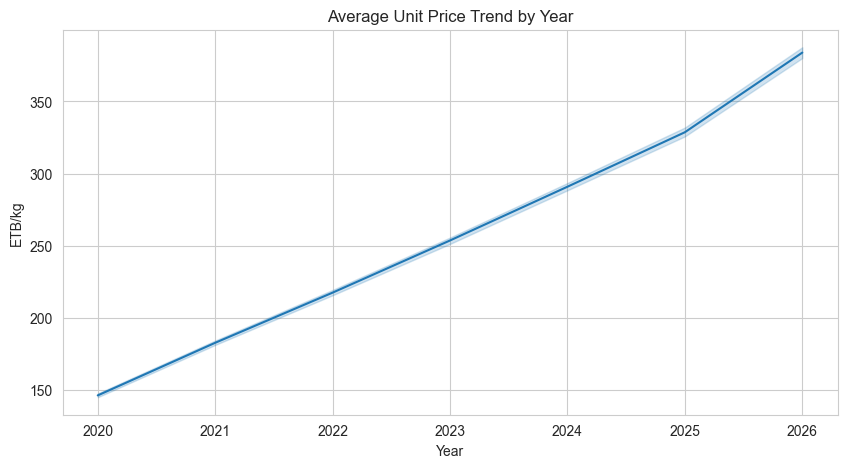


Processed data saved: ../data/processed_rebar_sales.csv


In [15]:
print("\nFinal shape:", df.shape)
print("\nMissing values after processing:\n", df.isna().sum())
print("\nProcessed columns:\n", df.columns.tolist())

# Quick visual sanity check (price trend over years)
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Year', y='Unit_Price_ETB_kg', errorbar='ci')
plt.title('Average Unit Price Trend by Year')
plt.ylabel('ETB/kg')
plt.show()

# Save cleaned & enriched data
df.to_csv('../data/processed_rebar_sales.csv', index=False)
print("\nProcessed data saved: ../data/processed_rebar_sales.csv")